In [2]:
from pathlib import Path
# In a Jupyter notebook, __file__ is not defined, so use the notebook working directory.
base = Path.cwd()

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from itertools import combinations

# ----------------------------------------------------
# 3) RBF Kernel
# ----------------------------------------------------
def rbf_kernel(x1, x2, gamma):
    return np.exp(-gamma * np.sum((x1 - x2)**2))

def compute_kernel_matrix(X, gamma):
    # cdist를 사용해 모든 데이터 포인트 간의 유클리디안 거리의 제곱을 한 번에 계산
    sq_dists = cdist(X, X, metric='sqeuclidean')
    return np.exp(-gamma * sq_dists)

# ----------------------------------------------------
# 4) 결정 함수, 예측 함수, 결정 경계 시각화 
# ----------------------------------------------------
def decision_function(alpha, b, X_train, t_train, gamma, X_test):
    """
    f(X) = K(X_test, X_train) * (alpha * t) + b
    for문 없이 행렬 곱셈으로 한 번에 계산합니다.
    """
    # 1. X_test(M개)와 X_train(N개) 간의 모든 유클리디안 거리 제곱을 한 번에 계산 (M x N 행렬)
    sq_dists = cdist(X_test, X_train, metric='sqeuclidean')
    
    # 2. RBF 커널 적용
    K_test = np.exp(-gamma * sq_dists)
    
    # 3. 각 학습 데이터의 가중치 계산 (alpha_n * t_n)
    weights = alpha * t_train
    
    # 4. 행렬 곱셈(np.dot)을 통해 M개의 결과값을 1초 만에 계산 후 b 더하기
    vals = np.dot(K_test, weights) + b
    
    return vals

def predict(alpha, b, X_train, t_train, gamma, X_test):
    vals = decision_function(alpha, b, X_train, t_train, gamma, X_test)
    return np.sign(vals)

def plot_decision_boundary(alpha, b, X, t, gamma, title="RBF SVM", feature_indices=(0, 1), ax=None, show_legend=False):
    """Plot a 2D slice of the decision function for higher-dimensional data."""
    if X.ndim != 2 or X.shape[1] < 2:
        raise ValueError("plot_decision_boundary requires X with at least 2 features.")

    if len(feature_indices) != 2:
        raise ValueError("feature_indices must be a pair of feature indices.")

    if ax is None:
        ax = plt.gca()

    X_plot = X[:, feature_indices]
    x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
    y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # For higher-dimensional data, fix the remaining features to their training set means.
    if X.shape[1] > 2:
        fixed_values = np.mean(X, axis=0)
        full_grid = np.tile(fixed_values, (grid_points.shape[0], 1))
        full_grid[:, feature_indices[0]] = grid_points[:, 0]
        full_grid[:, feature_indices[1]] = grid_points[:, 1]
    else:
        full_grid = grid_points

    Z = predict(alpha, b, X, t, gamma, full_grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.bwr)

    for label, marker, color in zip([1, -1], ['o', 'o'], ['blue', 'red']):
        ax.scatter(X_plot[t == label, 0], X_plot[t == label, 1],
                   marker=marker, c=color, label=f"Class {label}", edgecolor='k', s=20)

    ax.set_title(title)
    ax.grid(True)
    if show_legend:
        ax.legend(fontsize='small')


def plot_pairwise_decision_boundaries(alpha, b, X, t, gamma, feature_names=None, figsize=(18, 16)):
    n_features = X.shape[1]
    if n_features < 2:
        raise ValueError("Need at least 2 features to plot pairwise decision boundaries.")

    if feature_names is None:
        feature_names = [f"x{i+1}" for i in range(n_features)]

    combos = list(combinations(range(n_features), 2))
    n_plots = len(combos)
    cols = 3
    rows = (n_plots + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes_flat = axes.flatten()

    for ax, (i, j) in zip(axes_flat, combos):
        title = f"{feature_names[i]} vs {feature_names[j]}"
        plot_decision_boundary(
            alpha, b, X, t, gamma,
            title=title,
            feature_indices=(i, j),
            ax=ax,
            show_legend=False
        )

    for ax in axes_flat[n_plots:]:
        ax.axis('off')

    fig.suptitle("Pairwise 2D Decision Boundaries (4D SVM)", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    return fig


# ----------------------------------------------------
# 5) Soft-Margin RBF SVM
# ----------------------------------------------------
#
# 프라이멀에서는 파라미터 'C'와 slack variable을 고려하지만,
# 듀얼에서는 alpha_n <= C가 추가 제약이 된다.
# 즉, 소프트 마진에서는:
#   0 <= alpha_n <= C
#

def dual_objective_soft(alpha, t, K):
    """
    Dual objective:
       maximize W(alpha) = sum(alpha_n) - 1/2 sum_{n,m} alpha_n alpha_m t_n t_m K(n,m)
    We'll minimize the negative of W(alpha).
    """
    term1 = 0.5 * np.sum((alpha * t)[:, None] * (alpha * t)[None, :] * K)
    term2 = np.sum(alpha)
    return term1 - term2

def dual_gradient_soft(alpha, t, K):
    """
    W(alpha)에 대한 alpha의 편미분 (기울기)
    최소화 문제이므로 부호를 반대로 적용
    """
    return np.dot(K, alpha * t) * t - 1.0

def fit_svm_rbf_soft(X, t, gamma, C):
    """
    Solve the Soft-Margin SVM dual problem:
       0 <= alpha_n <= C
       sum_n alpha_n t_n = 0
    """
    N = len(X)
    K = compute_kernel_matrix(X, gamma=gamma)

    alpha0 = np.zeros(N)
    
    def eq_constraint(alpha):
        return np.dot(alpha, t)

    constraints = [{'type': 'eq', 'fun': eq_constraint}]
    bounds = [(0, C)] * N # 소프트 마진: alpha_n <= C

    res = minimize(
        fun=dual_objective_soft,
        x0=alpha0,
        args=(t, K),
        jac=dual_gradient_soft,
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 1000, 'disp': True}
    )
    alpha_opt = res.x

    # b 계산 (KKT)
    sv_indices = np.where((alpha_opt > 1e-8) & (alpha_opt <= C ))[0]
    if len(sv_indices) == 0:
        b_opt = 0.0
    else:
        b_list = []
        for i in sv_indices:
            sum_j = np.sum(alpha_opt * t * K[i, :])
            b_i = t[i] - sum_j
            b_list.append(b_i)
        b_opt = np.mean(b_list)

    return alpha_opt, b_opt

# ----------------------------------------------------
# 6) 예시 실행 (gamma와 C값을 튜닝 해볼 것)
# ----------------------------------------------------
X_train = np.loadtxt(base / "X_train.csv", delimiter=",")
t_train = np.loadtxt(base / "t_train.csv", delimiter=",")
X_test = np.loadtxt(base / "X_test.csv", delimiter=",")
t_test = np.loadtxt(base / "t_test.csv", delimiter=",")


In [3]:
# 탐색할 C와 gamma의 후보군을 리스트로 정의합니다.
# 보통 로그 스케일(0.01, 0.1, 1, 10, 100 등)로 넓게 탐색한 뒤, 
# 성능이 좋은 구간을 좁혀서 다시 탐색하는 것이 좋습니다.

C_candidates = [0.1, 1.0, 10.0]
gamma_candidates = [0.1, 1.0, 10.0]

best_acc = 0.0
best_params = {'C': None, 'gamma': None}
best_model = {'alpha': None, 'b': None}

print("--- 하이퍼파라미터 탐색(Grid Search) 시작 ---")

for C_val in C_candidates:
    for gamma_val in gamma_candidates:
        # 1. 해당 파라미터 조합으로 모델 학습
        alpha_opt, b_opt = fit_svm_rbf_soft(X_train, t_train, gamma=gamma_val, C=C_val)
        
        # 2. 벡터화된 predict 함수로 테스트 데이터 예측
        t_pred = predict(alpha_opt, b_opt, X_train, t_train, gamma=gamma_val, X_test=X_test)
        
        # 3. 정확도(Accuracy) 계산
        acc = np.mean(t_test == t_pred)
        print(f"[C={C_val:4.1f}, gamma={gamma_val:4.1f}] Test Accuracy: {acc * 100:.2f}%")
        
        # 4. 기존 최고 성능보다 좋으면 기록 갱신
        if acc > best_acc:
            best_acc = acc
            best_params = {'C': C_val, 'gamma': gamma_val}
            best_model = {'alpha': alpha_opt, 'b': b_opt}

print("\n=== 🏆 최적화 결과 ===")
print(f"최고 정확도: {best_acc * 100:.2f}%")
print(f"최적의 하이퍼파라미터: C={best_params['C']}, gamma={best_params['gamma']}")

--- 하이퍼파라미터 탐색(Grid Search) 시작 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: -28.75307757610549
            Iterations: 2
            Function evaluations: 2
            Gradient evaluations: 2
[C= 0.1, gamma= 0.1] Test Accuracy: 53.00%
Optimization terminated successfully    (Exit mode 0)
            Current function value: -28.033947328662634
            Iterations: 2
            Function evaluations: 2
            Gradient evaluations: 2
[C= 0.1, gamma= 1.0] Test Accuracy: 60.00%
Optimization terminated successfully    (Exit mode 0)
            Current function value: -28.488372374269467
            Iterations: 2
            Function evaluations: 2
            Gradient evaluations: 2
[C= 0.1, gamma=10.0] Test Accuracy: 59.00%
Optimization terminated successfully    (Exit mode 0)
            Current function value: -245.52419246773016
            Iterations: 34
            Function evaluations: 37
            Gradient evaluations: 34
[C

In [4]:
# [두번째 시도]
C_candidates = [0.5, 1.0, 2.0, 3.0, 5.0]
gamma_candidates = [0.5, 1.0, 2.0, 3.0, 5.0]



best_acc = 0.0
best_params = {'C': None, 'gamma': None}
best_model = {'alpha': None, 'b': None}

print("--- 하이퍼파라미터 탐색(Grid Search) 시작 ---")

for C_val in C_candidates:
    for gamma_val in gamma_candidates:
        # 1. 해당 파라미터 조합으로 모델 학습
        alpha_opt, b_opt = fit_svm_rbf_soft(X_train, t_train, gamma=gamma_val, C=C_val)
        
        # 2. 벡터화된 predict 함수로 테스트 데이터 예측
        t_pred = predict(alpha_opt, b_opt, X_train, t_train, gamma=gamma_val, X_test=X_test)
        
        # 3. 정확도(Accuracy) 계산
        acc = np.mean(t_test == t_pred)
        print(f"[C={C_val:4.1f}, gamma={gamma_val:4.1f}] Test Accuracy: {acc * 100:.2f}%")
        
        # 4. 기존 최고 성능보다 좋으면 기록 갱신
        if acc > best_acc:
            best_acc = acc
            best_params = {'C': C_val, 'gamma': gamma_val}
            best_model = {'alpha': alpha_opt, 'b': b_opt}

print("\n=== 🏆 최적화 결과 ===")
print(f"최고 정확도: {best_acc * 100:.2f}%")
print(f"최적의 하이퍼파라미터: C={best_params['C']}, gamma={best_params['gamma']}")

--- 하이퍼파라미터 탐색(Grid Search) 시작 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: -114.37691314181595
            Iterations: 18
            Function evaluations: 20
            Gradient evaluations: 18
[C= 0.5, gamma= 0.5] Test Accuracy: 61.00%
Optimization terminated successfully    (Exit mode 0)
            Current function value: -110.16427452761317
            Iterations: 23
            Function evaluations: 23
            Gradient evaluations: 23
[C= 0.5, gamma= 1.0] Test Accuracy: 62.00%
Optimization terminated successfully    (Exit mode 0)
            Current function value: -109.17643667432733
            Iterations: 15
            Function evaluations: 15
            Gradient evaluations: 15
[C= 0.5, gamma= 2.0] Test Accuracy: 59.00%
Optimization terminated successfully    (Exit mode 0)
            Current function value: -110.10930653328592
            Iterations: 12
            Function evaluations: 12
            Gradient evaluati

In [5]:
# [세번째 시도]
C_candidates = [0.2, 0.5, 0.8, 1.5, 2.0, 2.5]
gamma_candidates = [0.3, 0.5, 0.8, 1.0, 1.2]



best_acc = 0.0
best_params = {'C': None, 'gamma': None}
best_model = {'alpha': None, 'b': None}

print("--- 하이퍼파라미터 탐색(Grid Search) 시작 ---")

for C_val in C_candidates:
    for gamma_val in gamma_candidates:
        # 1. 해당 파라미터 조합으로 모델 학습
        alpha_opt, b_opt = fit_svm_rbf_soft(X_train, t_train, gamma=gamma_val, C=C_val)
        
        # 2. 벡터화된 predict 함수로 테스트 데이터 예측
        t_pred = predict(alpha_opt, b_opt, X_train, t_train, gamma=gamma_val, X_test=X_test)
        
        # 3. 정확도(Accuracy) 계산
        acc = np.mean(t_test == t_pred)
        print(f"[C={C_val:4.1f}, gamma={gamma_val:4.1f}] Test Accuracy: {acc * 100:.2f}%")
        
        # 4. 기존 최고 성능보다 좋으면 기록 갱신
        if acc > best_acc:
            best_acc = acc
            best_params = {'C': C_val, 'gamma': gamma_val}
            best_model = {'alpha': alpha_opt, 'b': b_opt}

print("\n=== 🏆 최적화 결과 ===")
print(f"최고 정확도: {best_acc * 100:.2f}%")
print(f"최적의 하이퍼파라미터: C={best_params['C']}, gamma={best_params['gamma']}")

--- 하이퍼파라미터 탐색(Grid Search) 시작 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: -52.17907523825416
            Iterations: 11
            Function evaluations: 11
            Gradient evaluations: 11
[C= 0.2, gamma= 0.3] Test Accuracy: 52.00%
Optimization terminated successfully    (Exit mode 0)
            Current function value: -51.74891750176874
            Iterations: 15
            Function evaluations: 16
            Gradient evaluations: 15
[C= 0.2, gamma= 0.5] Test Accuracy: 59.00%
Optimization terminated successfully    (Exit mode 0)
            Current function value: -51.990265010091505
            Iterations: 9
            Function evaluations: 9
            Gradient evaluations: 9
[C= 0.2, gamma= 0.8] Test Accuracy: 59.00%
Optimization terminated successfully    (Exit mode 0)
            Current function value: -52.242393760457965
            Iterations: 9
            Function evaluations: 9
            Gradient evaluations: 9


In [6]:
C_candidates = [0.6, 0.7, 0.8, 0.9, 1.0]
gamma_candidates = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1]

best_acc = 0.0
best_params = {'C': None, 'gamma': None}
best_model = {'alpha': None, 'b': None}

print("--- 하이퍼파라미터 탐색(Grid Search) 시작 ---")

for C_val in C_candidates:
    for gamma_val in gamma_candidates:
        # 1. 해당 파라미터 조합으로 모델 학습
        alpha_opt, b_opt = fit_svm_rbf_soft(X_train, t_train, gamma=gamma_val, C=C_val)
        
        # 2. 벡터화된 predict 함수로 테스트 데이터 예측
        t_pred = predict(alpha_opt, b_opt, X_train, t_train, gamma=gamma_val, X_test=X_test)
        
        # 3. 정확도(Accuracy) 계산
        acc = np.mean(t_test == t_pred)
        print(f"[C={C_val:4.1f}, gamma={gamma_val:4.1f}] Test Accuracy: {acc * 100:.2f}%")
        
        # 4. 기존 최고 성능보다 좋으면 기록 갱신
        if acc > best_acc:
            best_acc = acc
            best_params = {'C': C_val, 'gamma': gamma_val}
            best_model = {'alpha': alpha_opt, 'b': b_opt}

print("\n=== 🏆 최적화 결과 ===")
print(f"최고 정확도: {best_acc * 100:.2f}%")
print(f"최적의 하이퍼파라미터: C={best_params['C']}, gamma={best_params['gamma']}")

--- 하이퍼파라미터 탐색(Grid Search) 시작 ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: -136.03861022624568
            Iterations: 20
            Function evaluations: 24
            Gradient evaluations: 20
[C= 0.6, gamma= 0.4] Test Accuracy: 61.00%
Optimization terminated successfully    (Exit mode 0)
            Current function value: -133.6003965691559
            Iterations: 20
            Function evaluations: 22
            Gradient evaluations: 20
[C= 0.6, gamma= 0.5] Test Accuracy: 63.00%
Optimization terminated successfully    (Exit mode 0)
            Current function value: -131.63669656045494
            Iterations: 20
            Function evaluations: 23
            Gradient evaluations: 20
[C= 0.6, gamma= 0.6] Test Accuracy: 64.00%
Optimization terminated successfully    (Exit mode 0)
            Current function value: -130.0225477961817
            Iterations: 19
            Function evaluations: 21
            Gradient evaluation

Saved optimal pairwise decision boundary figure to: d:\Workspace\KNOU\[6-1]머신러닝\기말과제\best_decision_boundaries.png


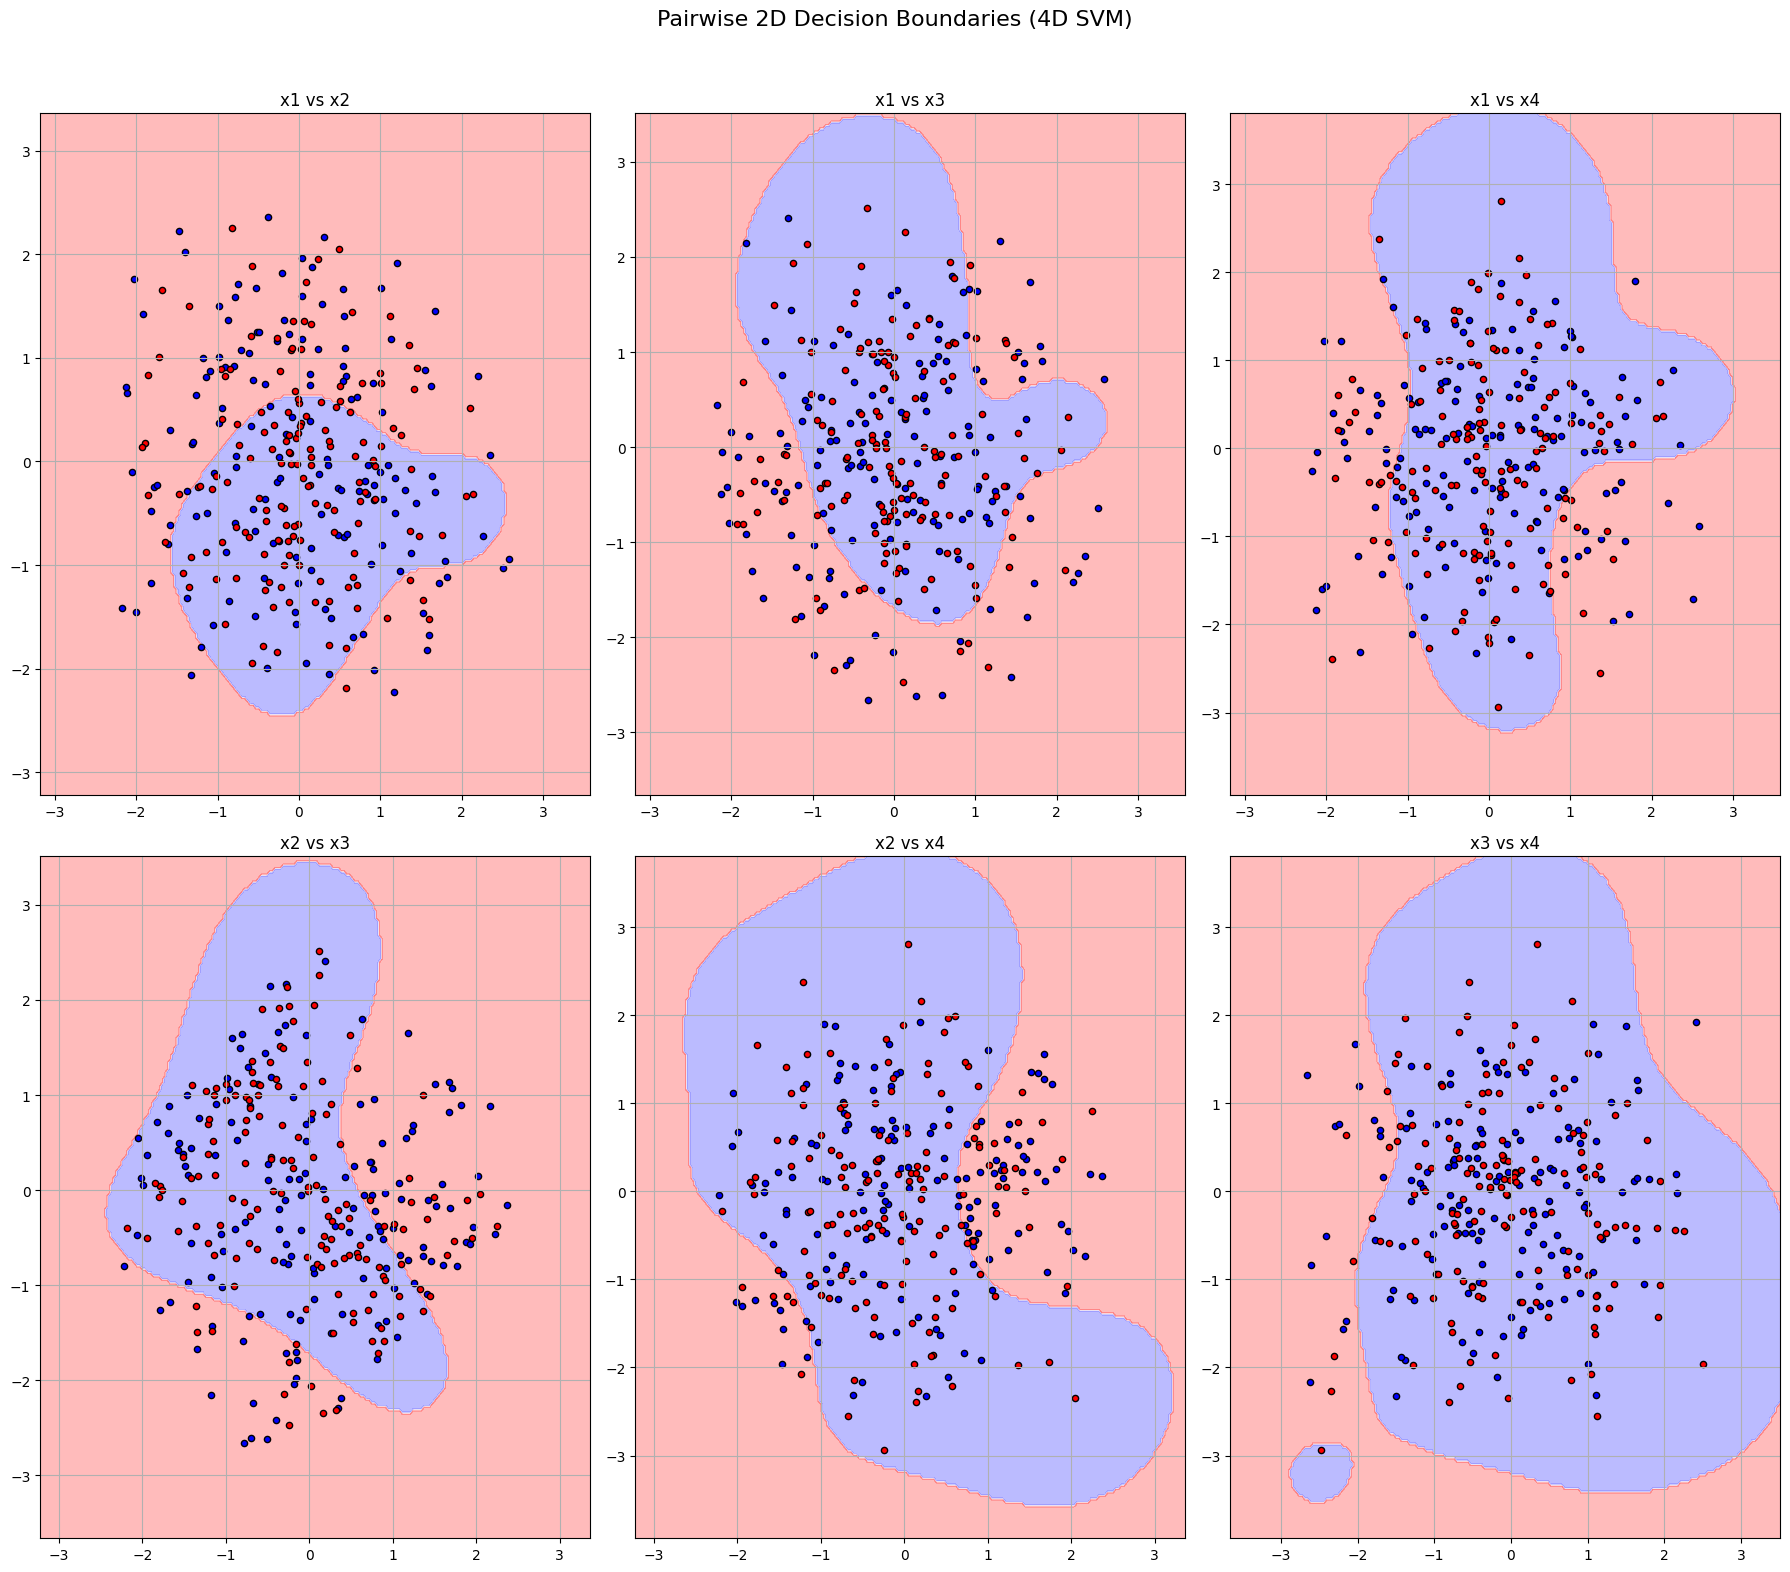

In [7]:
# ----------------------------------------------------
# 8) 최적의 모델로 결정 경계 시각화
# ----------------------------------------------------
# 가장 성능이 좋았던 파라미터로 그래프를 그립니다.
fig = plot_pairwise_decision_boundaries(
    best_model['alpha'], best_model['b'], X_train, t_train, best_params['gamma'],
    feature_names=[f"x{i+1}" for i in range(X_train.shape[1])],
    figsize=(18, 16)
)
output_path = base / "best_decision_boundaries.png"
fig.savefig(output_path, dpi=150)
print(f"Saved optimal pairwise decision boundary figure to: {output_path}")
plt.show()